In [1]:
import sys
import os
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)
from evaluation import compare_bpmn_files
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
import numpy as np
import seaborn as sns

## 1. Evaluation of all processes + Input data

In [19]:
all_results_new = pd.DataFrame(columns=["Process", "GEDavg", "GED1", "GED2", "GED3"])
input_path = "./data/friedrich/"
for folder in os.listdir(input_path):
    bpmn_folder_path = input_path + folder + "/3-bpmn/"
    for file in os.listdir(bpmn_folder_path):
        base_name = os.path.splitext(file)[0]
        bpmn_true = bpmn_folder_path + file
        bpmn_1 = "./output/quantitative-evaluation/" + folder + "/" + base_name + "/model.bpmn"
        bpmn_2 = "./output/quantitative-evaluation/" + folder + "/" + base_name + "/model_1.bpmn"
        bpmn_3 = "./output/quantitative-evaluation/" + folder + "/" + base_name + "/model_2.bpmn"
        ged_1 = compare_bpmn_files(bpmn_true, bpmn_1)
        ged_2 = compare_bpmn_files(bpmn_true, bpmn_2)
        ged_3 = compare_bpmn_files(bpmn_true, bpmn_3)
        avg = (ged_1+ged_2+ged_3)/3
        all_results_new = pd.concat([all_results_new, pd.DataFrame({"Process": [folder + "-" + base_name], "GEDavg": [avg], "GED1": [ged_1], "GED2": [ged_2], "GED3": [ged_3]})])

In [ ]:
# add the input statistics
input_statistics = pd.DataFrame([
    ['BPM practitioner + practical handbook-Frank', 34, 7, 57, 7, 12, 10],
    ['BPM practitioner + practical handbook-HRdepartment', 32, 7, 88, 8, 13, 16],
    ['BPM practitioner + practical handbook-HRfunctional', 36, 6, 87, 8, 15, 21],
    ['BPM practitioner + practical handbook-SimpleHR', 20, 3, 47, 5, 12, 6],
    ['BPM Vendor Tutorials-BizAgi1', 44, 5, 82, 7, 13, 8],
    ['BPM Vendor Tutorials-BizAgi2', 80, 10, 196, 7, 17, 12],
    ['BPM Vendor Tutorials-VOS', 36, 6, 83, 4, 7, 6],
    ['BPMN modeling and reference guide-Ex2', 45, 5, 98, 10, 20, 17],
    ['BPMN modeling and reference guide-Ex3a', 34, 4, 81, 8, 19, 16],
    ['BPMN modeling and reference guide-Ex3b', 43, 5, 98, 10, 21, 17],
    ['BPMN modeling and reference guide-Ex4', 55, 7, 117, 6, 18, 21],
    ['Fed-B2', 19, 3, 29, 8, 14, 13],
    ['Fed-B3', 120, 14, 240, 13, 55, 64],
    ['Fed-B4', 72, 11, 128, 8, 31, 33],
    ['Fed-B5-1', 55, 9, 118, 7, 35, 41],
    ['Fed-B5-2', 20, 4, 43, 6, 10, 9],
    ['Fed-B6', 20, 3, 30, 8, 14, 13],
    ['Fed-B7', 33, 7, 69, 9, 21, 20],
    ['Fed-B8', 38, 7, 77, 9, 19, 19],
    ['Fed-C1', 41, 5, 66, 6, 18, 21],
    ['Fed-C2', 53, 8, 107, 8, 26, 28],
    ['Fed-D1', 22, 4, 51, 8, 18, 16],
    ['Fed-D2', 21, 5, 39, 8, 14, 13],
    ['Fed-D3', 51, 5, 117, 8, 39, 48],
    ['HU-bicycle', 62, 12, 159, 7, 21, 19],
    ['HU-hotel-service', 71, 15, 160, 8, 28, 28],
    ['inubit-ACME', 196, 20, 414, 9, 36, 36],
    ['inubit-Powerlicht', 75, 12, 187, 7, 14, 10],
    ['inubit-Turbopixel', 76, 14, 190, 10, 28, 23],
    ['inubit-Tutorial', 28, 5, 56, 4, 8, 6],
    ['QUT-2009-1', 51, 7, 104, 7, 17, 18],
    ['QUT-2009-2', 32, 4, 76, 5, 12, 13],
    ['QUT-2009-3', 29, 5, 71, 4, 8, 8],
    ['QUT-2009-4', 28, 4, 72, 7, 8, 8],
    ['QUT-2009-5', 65, 9, 154, 10, 34, 38],
    ['QUT-2010-1', 42, 8, 103, 4, 12, 12],
    ['QUT-2010-2', 37, 5, 88, 4, 13, 15],
    ['QUT-2010-3', 42, 7, 98, 7, 17, 16],
    ['TUB-SLA-violation', 308, 42, 698, 11, 73, 84],
    ['TUE-intaker-workflow', 273, 40, 668, 9, 38, 37],
], columns=[
    'Process',
    'audio',
    'sentences',
    'words',
    'distinct elements',
    'total elements',
    'connections'
])

In [6]:
# add the statistics of the generated models
results_statistics = pd.DataFrame([
    ['BPM practitioner + practical handbook-Frank', 5.33, 6,4,6, 13.3, 16,11,13, 11.6, 13,12,10],
    ['BPM practitioner + practical handbook-HRdepartment', 6.33, 6,7,6, 14.6, 14,15,15, 12.3, 12,12,13],
    ['BPM practitioner + practical handbook-HRfunctional', 7, 9,6,6, 22, 26,22,18, 23.3, 30,24,16],
    ['BPM practitioner + practical handbook-SimpleHR', 4, 3,5,4, 7.6, 6,9,8, 5, 5,5,5],
    ['BPM Vendor Tutorials-BizAgi1', 6, 6,6,6, 14, 14,14,14, 9, 9,9,9],
    ['BPM Vendor Tutorials-BizAgi2', 7.3, 7,7,8, 23.3, 24,23,23, 18.3, 19,18,18],
    ['BPM Vendor Tutorials-VOS', 5, 6,4,5, 13.3, 18,12,11, 13, 14,14,11],
    ['BPMN modeling and reference guide-Ex2', 7, 7,7,7, 16.6, 16,17,17, 13.6, 13,13,15],
    ['BPMN modeling and reference guide-Ex3a', 5.6, 5,6,5, 12.6, 12,15,11, 7.6, 7,10,6],
    ['BPMN modeling and reference guide-Ex3b', 5, 5,5,5, 14.6, 14,14,16, 9.6, 9,9,11],
    ['BPMN modeling and reference guide-Ex4', 7.3, 6,8,8, 22, 20,24,22, 18.3, 17,19,19],
    ['Fed-B2', 5.6, 5,6,6, 12.3, 14,12,11, 7.6, 9,7,7],
    ['Fed-B3', 6.6, 8,8,6, 38, 36,36,41, 31, 33,29,33],
    ['Fed-B4', 6, 6,6,6, 18.6, 18,18,20, 15, 15,15,15],
    ['Fed-B5-1', 5.3, 4,6,6, 22.3, 16,25,26, 20.3, 16,22,23],
    ['Fed-B5-2', 5, 6,4,5, 14.6, 20,11,13, 13.3, 18,11,11],
    ['Fed-B6', 6, 6,6,6, 14, 14,14,14, 9, 9,9,9],
    ['Fed-B7', 7, 8,6,7, 18.6, 22,18,16, 13, 17,9,13],
    ['Fed-B8', 6, 6,6,6, 15.6, 15,15,17, 9.6, 9,9,11],
    ['Fed-C1', 6.3, 5,6,8, 16.3, 18,15,16, 14, 15,11,16],
    ['Fed-C2', 6, 6,6,6, 23.6, 39,15,17, 21, 30,16,17],
    ['Fed-D1', 7.3, 8,7,7, 24.6, 23,26,25, 19.6, 18,20,21],
    ['Fed-D2', 6.3, 5,7,7, 13, 12,12,15, 10.6, 8,12,12],
    ['Fed-D3', 6.3, 5,6,8, 37.3, 50,39,23, 38, 52,41,21],
    ['HU-bicycle', 7.6, 8,7,7, 15, 15,15,15, 11, 11,11,11],
    ['HU-hotel-service', 6.3, 6,6,7, 19, 19,19,19, 15, 17,14,14],
    ['inubit-ACME', 7, 6,8,7, 27.3, 27,27,28, 23, 25,20,24],
    ['inubit-Powerlicht', 6.3, 4,7,8, 15, 10,19,16, 12.6, 10,14,14],
    ['inubit-Turbopixel', 7.3, 7,7,8, 22, 16,24,25, 18, 18,16,20],
    ['inubit-Tutorial', 5, 5,5,5, 12.6, 13,13,12, 9, 10,9,8],
    ['QUT-2009-1', 6, 6,6,6, 17, 20,13,18, 13.3, 14,11,15],
    ['QUT-2009-2', 5.6, 6,5,5, 12.6, 14,12,12, 13, 13,13,13],
    ['QUT-2009-3', 6, 6,6,6, 9.3, 10,9,9, 6.3, 7,6,6],
    ['QUT-2009-4', 7, 8,8,5, 12, 10,13,13, 9.3, 9,10,9],
    ['QUT-2009-5', 5.6, 7,5,5, 17.3, 20,16,16, 16.6, 18,16,16],
    ['QUT-2010-1', 5, 4,6,5, 16.3, 17,17,15, 15.3, 18,15,13],
    ['QUT-2010-2', 6.6, 6,7,7, 12.3, 11,14,12, 8, 6,12,6],
    ['QUT-2010-3', 6.3, 6,7,7, 14.3, 14,15,15, 11, 11,11,11],
    ['TUB-SLA-violation', 8.6, 8,11,7, 56.3, 50,65,54, 56.6, 51,61,58],
    ['TUE-intaker-workflow', 9, 8,10,9, 37.3, 42,34,34, 31.6, 37,29,29],
], columns=[
    'Process',
    'distinctavg',
    'distinct1',
    'distinct2',
    'distinct3',
    'elementsavg',
    'elements1',
    'elements2',
    'elements3',
    'connectionsavg',
    'connections1',
    'connections2',
    'connections3',
])

In [18]:
# add information on the error cases
error_cases = pd.DataFrame([
    ['BPM practitioner + practical handbook-Frank', 1, 1, 0, 0, 0, 0],
    ['BPM Vendor Tutorials-BizAgi2', 3, 0, 0, 1, 0, 0],
    ['Fed-B3', 1, 0, 0, 1, 0, 0],
    ['Fed-B3', 2, 0, 0, 0, 1, 0],
    ['Fed-B3', 3, 1, 1, 0, 0, 0],
    ['Fed-B5-2', 2, 1, 0, 0, 0, 0],
    ['Fed-C1', 1, 1, 0, 0, 0, 0],
    ['Fed-C2', 2, 1, 0, 0, 0, 0],
    ['Fed-D2', 2, 1, 0, 0, 0, 0],
    ['Fed-D3', 1, 1, 0, 0, 0, 0],
    ['Fed-D3', 2, 1, 0, 0, 0, 0],
    ['Fed-D3', 3, 0, 1, 1, 0, 0],
    ['inubit-ACME', 1, 0, 0, 0, 1, 0],
    ['inubit-Powerlicht', 2, 1, 0, 0, 0, 0],
    ['inubit-Turbopixel', 2, 0, 1, 1, 0, 0],
    ['QUT-2009-3', 1, 0, 0, 0, 1, 0],
    ['QUT-2009-4', 2, 1, 1, 0, 0, 0],
    ['QUT-2009-4', 3, 1, 0, 0, 0, 0],
    ['QUT-2010-1', 2, 0, 0, 0, 1, 0],
    ['TUE-intaker-workflow', 1, 0, 0, 0, 0, 1],
    ['TUE-intaker-workflow', 2, 0, 0, 0, 0, 1],
], columns=[
    'Process',
    'number',
    'messageFlow',
    'missingFlow',
    'flowCrossingPoolBoundary',
    'gatewayWithoutFunction',
    'wrongFlow',
])

## 2. Preprocessing: Generate dataframes for the different analysis:
`full_df`: contains all data, with each row being one generated process<br>
`non_error_data`: contains the data of all processes that did not have errors<br>
`error_data`: contains the data of all processes that have errors<br>

In [51]:
non_error_cases = pd.DataFrame([], columns=['Process', 'number', 'GED', 'resultDistinct', 'resultElements', 'resultConnections'])
for idx, row in all_results_new.iterrows():
    process = row['Process']
    for i in range(3):
        number = i+1
        ged_field = "GED"+str(i+1)
        ged = row[ged_field]
        distinct_field = "distinct"+str(i+1)
        elements_field = "elements"+str(i+1)
        connections_field = "connections"+str(i+1)
        distinct = results_statistics[results_statistics['Process'] == process][distinct_field]
        elements = results_statistics[results_statistics['Process'] == process][elements_field]
        connections = results_statistics[results_statistics['Process'] == process][connections_field]
        if distinct.empty or elements.empty or connections.empty:
            continue
        s = pd.DataFrame([[process, number, ged, distinct.values[0], elements.values[0], connections.values[0]]], columns=['Process', 'number', 'GED', 'resultDistinct', 'resultElements', 'resultConnections'])
        non_error_cases = pd.concat([non_error_cases, s])

In [54]:
to_remove = set(zip(error_cases['Process'], error_cases['number']))
non_error_cases = non_error_cases[~non_error_cases.set_index(['Process', 'number']).index.isin(to_remove)].reset_index(drop=True)

In [53]:
non_error_data = pd.merge(non_error_cases, input_statistics, how='left', on='Process')

In [19]:
temp = pd.merge(error_cases, input_statistics, how='left', on='Process')

In [20]:
temp["GED"] = None
temp["resultDistinct"] = None
temp["resultElements"] = None
temp["resultConnections"] = None

In [25]:
for idx, row in temp.iterrows():
    ged_field = "GED"+str(row["number"])
    distinct_field = "distinct"+str(row["number"])
    elements_field = "elements"+str(row["number"])
    connections_field = "connections"+str(row["number"])
    ged = all_results_new[all_results_new["Process"] == row["Process"]][ged_field]
    temp.loc[idx, "GED"] = ged.values[0] if not ged.empty else None
    distinct = results_statistics[results_statistics["Process"] == row["Process"]][distinct_field]
    elements = results_statistics[results_statistics["Process"] == row["Process"]][elements_field]
    connections = results_statistics[results_statistics["Process"] == row["Process"]][connections_field]
    temp.loc[idx, "resultDistinct"] = distinct.values[0] if not distinct.empty else None
    temp.loc[idx, "resultElements"] = elements.values[0] if not elements.empty else None
    temp.loc[idx, "resultConnections"] = connections.values[0] if not connections.empty else None

In [27]:
error_data = temp

In [75]:
results = pd.merge(all_results_new, results_statistics, on="Process")

In [76]:
full_df = pd.merge(results, input_statistics, on="Process")

In [77]:
full_df.describe()

,GEDavg,GED1,GED2,GED3,distinctavg,distinct1,distinct2,distinct3,elementsavg,elements1,...,connectionsavg,connections1,connections2,connections3,audio,sentences,words,distinct elements,total elements,connections
count,39.000000,39.000000,39.000000,39.000000,39.000000,39.000000,39.000000,39.000000,39.000000,39.000000,...,39.000000,39.000000,39.000000,39.000000,39.000000,39.000000,39.000000,39.000000,39.000000,39.000000
mean,0.647853,0.644711,0.644126,0.654722,6.250256,6.051282,6.410256,6.358974,18.879487,19.461538,...,15.638462,16.461538,15.384615,15.205128,61.615385,9.051282,137.410256,7.461538,21.358974,21.487179
std,0.084558,0.109511,0.095724,0.110895,1.007672,1.255487,1.427511,1.158201,9.428768,10.399509,...,9.716552,10.843009,10.186718,9.392549,62.780996,8.422866,146.225442,2.062780,13.476075,16.323815
min,0.463867,0.382526,0.368791,0.280203,4.000000,3.000000,4.000000,4.000000,7.600000,6.000000,...,5.000000,5.000000,5.000000,5.000000,19.000000,3.000000,29.000000,4.000000,7.000000,6.000000
25%,0.597082,0.588936,0.604741,0.609820,5.600000,5.000000,6.000000,5.500000,13.300000,14.000000,...,9.600000,9.000000,10.000000,10.500000,32.000000,5.000000,70.000000,6.500000,13.000000,12.000000
50%,0.654135,0.630838,0.635534,0.659010,6.300000,6.000000,6.000000,6.000000,15.600000,16.000000,...,13.000000,14.000000,12.000000,13.000000,42.000000,7.000000,98.000000,8.000000,18.000000,16.000000
75%,0.690873,0.729564,0.705415,0.710302,7.000000,7.000000,7.000000,7.000000,22.000000,20.000000,...,18.150000,18.000000,16.000000,17.500000,63.500000,9.500000,141.000000,8.500000,27.000000,25.500000
max,0.807048,0.871534,0.813447,0.891220,9.000000,8.000000,11.000000,9.000000,56.300000,50.000000,...,56.600000,52.000000,61.000000,58.000000,308.000000,42.000000,698.000000,13.000000,73.000000,84.000000


## 3. Analysis

### 3.1 Low Similarity Cases

In [115]:
filtered_df = full_df[
    (full_df["GED1"] < 0.46) |
    (full_df["GED2"] < 0.46) |
    (full_df["GED3"] < 0.46)
]
filtered_df

,Process,GEDavg,GED1,GED2,GED3,distinctavg,distinct1,distinct2,distinct3,elementsavg,...,connectionsavg,connections1,connections2,connections3,audio,sentences,words,distinct elements,total elements,connections
0,Fed-B8,0.589825,0.389613,0.670191,0.709670,6.0,6,6,6,15.6,...,9.6,9,9,11,38,7,77,9,19,19
4,Fed-B2,0.572160,0.574843,0.446113,0.695524,5.6,5,6,6,12.3,...,7.6,9,7,7,19,3,29,8,14,13
5,Fed-D3,0.463867,0.623206,0.488192,0.280203,6.3,5,6,8,37.3,...,38.0,52,41,21,51,5,117,8,39,48
6,Fed-D2,0.509555,0.530073,0.368791,0.629800,6.3,5,7,7,13.0,...,10.6,8,12,12,21,5,39,8,14,13
7,Fed-B3,0.559367,0.592808,0.628789,0.456504,6.6,8,8,6,38.0,...,31.0,33,29,33,120,14,240,13,55,64
25,inubit-Turbopixel,0.518248,0.382526,0.563385,0.608833,7.3,7,7,8,22.0,...,18.0,18,16,20,76,14,190,10,28,23
36,BPM Vendor Tutorials-VOS,0.484647,0.450273,0.589188,0.414481,5.0,6,4,5,13.3,...,13.0,14,14,11,36,6,83,4,7,6


In [106]:
filtered_df.to_excel("low_similarity_cases.xlsx", index=False)

### 3.2 GED Analysis

In [141]:
df_all_geds = pd.concat([full_df[col] for col in ["GED1", "GED2", "GED3"]])

In [157]:
df_all_distinct = pd.concat([full_df[col] for col in ["distinct1", "distinct2", "distinct3"]])
df_all_elements = pd.concat([full_df[col] for col in ["elements1", "elements2", "elements3"]])
df_all_connections = pd.concat([full_df[col] for col in ["connections1", "connections2", "connections3"]])

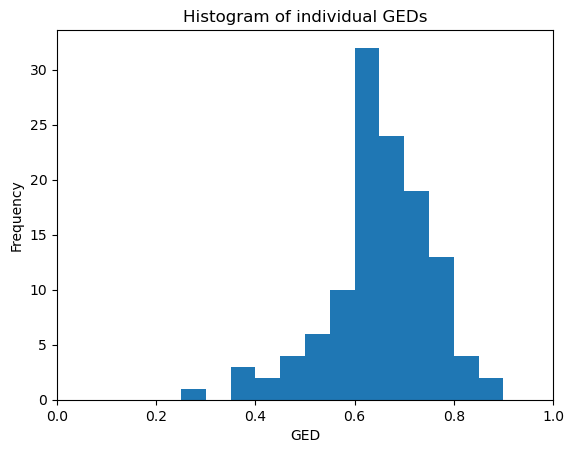

In [144]:
bin_edges = np.linspace(0,1,21)
plt.figure()
df_all_geds.plot(kind="hist", bins=bin_edges, title=f"Histogram of individual GEDs")
plt.xlabel("GED")
plt.ylabel("Frequency")
plt.xlim(0,1)
plt.show()

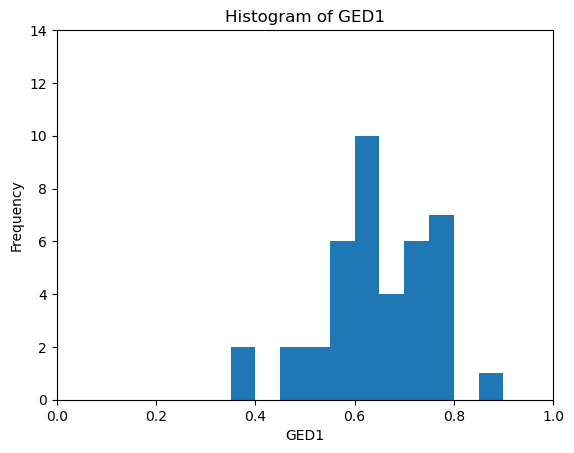

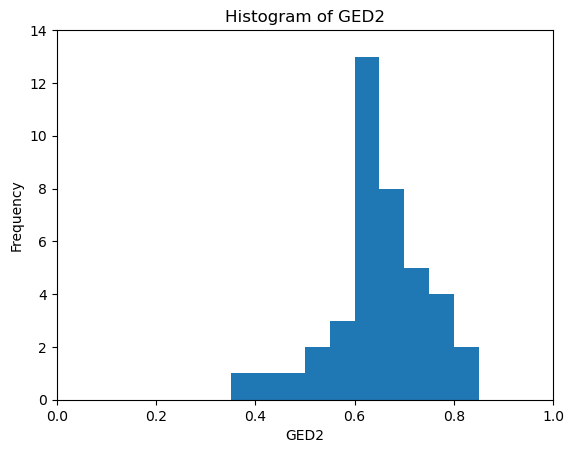

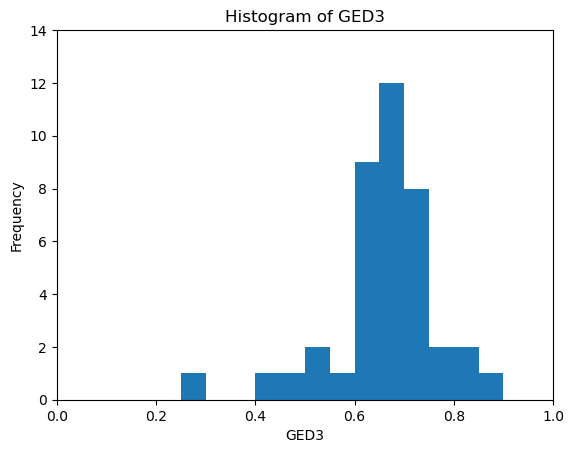

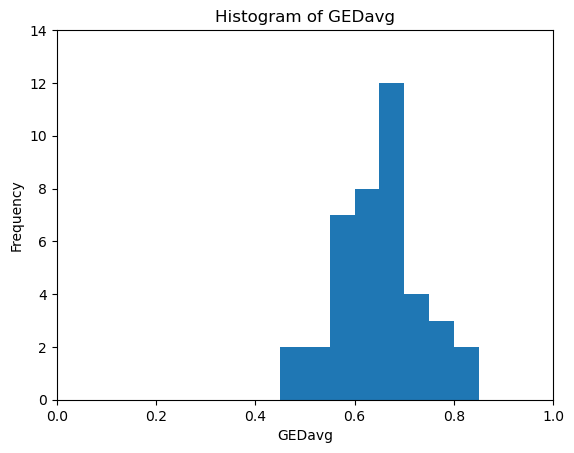

In [66]:
bin_edges = np.linspace(0,1,21)
for col in ["GED1", "GED2", "GED3", "GEDavg"]:
    plt.figure()
    full_df[col].plot(kind="hist", bins=bin_edges, title=f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.xlim(0,1)
    plt.ylim(0,14)
    plt.show()

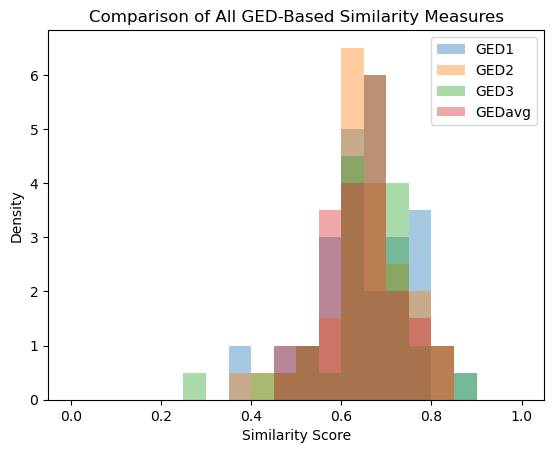

In [67]:
bin_edges = np.linspace(0,1,21)
plt.figure() 
for col in ["GED1", "GED2", "GED3", "GEDavg"]:
    plt.hist(
        full_df[col],
        bins=bin_edges,
        alpha=0.4,
        density=True,
        label=col
    )
plt.xlabel("Similarity Score")
plt.ylabel("Density")
plt.title("Comparison of All GED-Based Similarity Measures")
plt.legend()
plt.show()

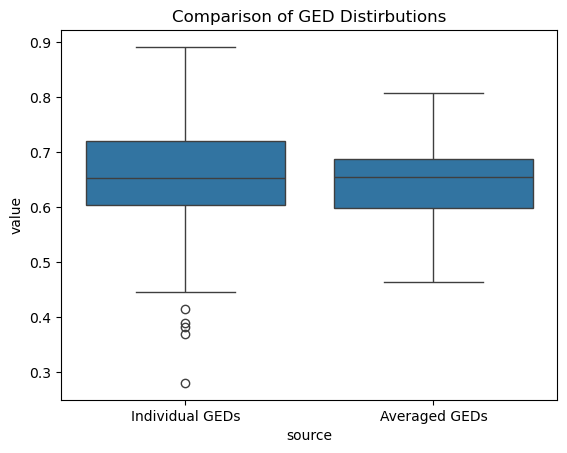

In [158]:
df_1_labeled = pd.DataFrame({"value": df_all_geds, "source": "Individual GEDs"})
df_2_labeled = pd.DataFrame({"value": full_df["GEDavg"], "source": "Averaged GEDs"})
boxplotvalues = pd.concat([df_1_labeled, df_2_labeled], ignore_index=True)
sns.boxplot(data=boxplotvalues, x='source', y='value')
plt.title('Comparison of GED Distirbutions')
plt.show()

### 3.3 Analysis of differences between generated models and ground truth models

<Figure size 640x480 with 0 Axes>

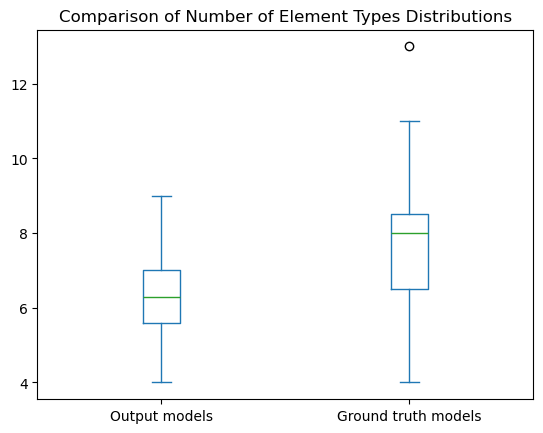

In [81]:
df_distinct = full_df[["distinctavg", "distinct elements"]].copy()
df_distinct.columns=["Output models", "Ground truth models"]
plt.figure()
df_distinct.plot(kind="box", title="Comparison of Number of Element Types Distributions")
plt.show()

<Figure size 640x480 with 0 Axes>

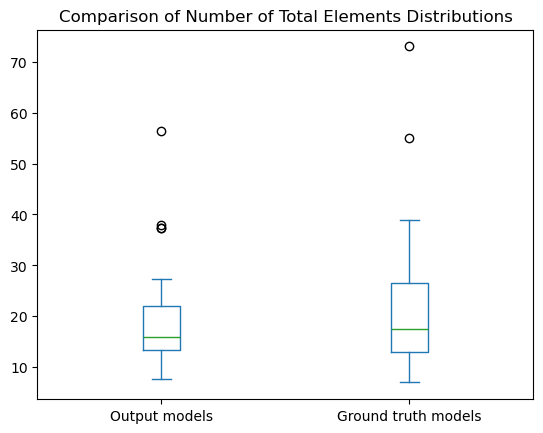

In [161]:
df_distinct = full_df[["elementsavg", "total elements"]].copy()
df_distinct.columns=["Output models", "Ground truth models"]
plt.figure()
df_distinct.plot(kind="box", title="Comparison of Number of Total Elements Distributions")
plt.show()

<Figure size 640x480 with 0 Axes>

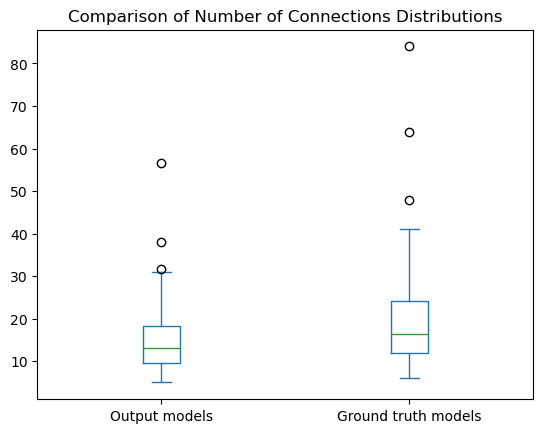

In [162]:
df_distinct = full_df[["connectionsavg", "connections"]].copy()
df_distinct.columns=["Output models", "Ground truth models"]
plt.figure()
df_distinct.plot(kind="box", title="Comparison of Number of Connections Distributions")
plt.show()

### 3.4 Correlation analysis

In [82]:
analysis_cols = [
    "GEDavg",
    "distinctavg",
    "elementsavg",
    "connectionsavg",
    "audio",
    "sentences",
    "words",
    "distinct elements",
    "total elements",
    "connections"
]

In [83]:
analysis_cols_naming = {
    "GEDavg": "GED",
    "distinctavg": "o - element types",
    "elementsavg": "o - total elements",
    "connectionsavg": "o - connections",
    "audio": "i - audio",
    "sentences": "i - sentences",
    "words": "i - words",
    "distinct elements": "gt - element types",
    "total elements": "gt - total elements",
    "connections": "gt - connections"
}

In [84]:
corr_matrix = full_df[analysis_cols].corr(method="pearson")
print("Pearson Correlation Matrix:")
print(corr_matrix, "\n")

Pearson Correlation Matrix:
                     GEDavg  distinctavg  elementsavg  connectionsavg  \
GEDavg             1.000000    -0.010861    -0.202527       -0.196878   
distinctavg       -0.010861     1.000000     0.632650        0.564438   
elementsavg       -0.202527     0.632650     1.000000        0.981457   
connectionsavg    -0.196878     0.564438     0.981457        1.000000   
audio              0.075824     0.660286     0.822139        0.793880   
sentences          0.119393     0.672754     0.782423        0.756832   
words              0.093888     0.678209     0.804561        0.779010   
distinct elements -0.263587     0.447230     0.578245        0.496309   
total elements    -0.174286     0.498404     0.906159        0.882511   
connections       -0.202029     0.461977     0.899632        0.891367   

                      audio  sentences     words  distinct elements  \
GEDavg             0.075824   0.119393  0.093888          -0.263587   
distinctavg        0.66028

Text(0.5, 1.0, 'Pearson Correlation Matrix Heatmap')

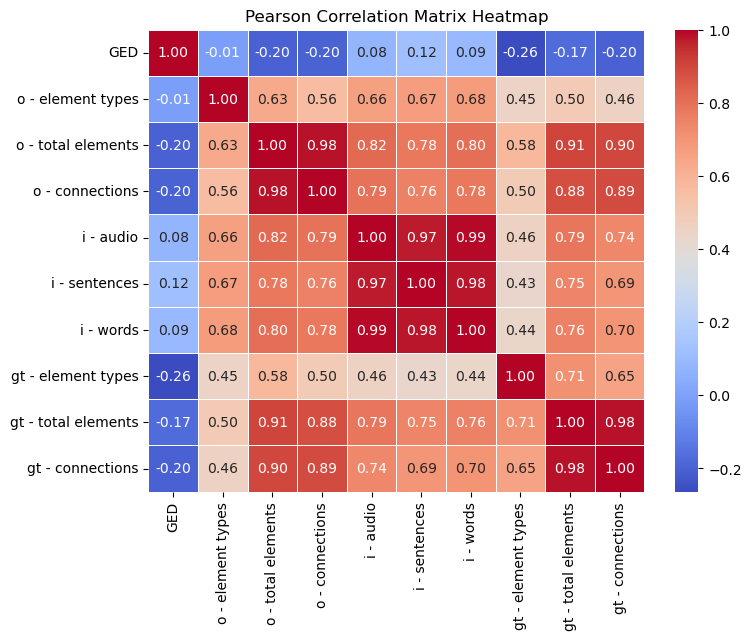

In [85]:
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, xticklabels=[analysis_cols_naming.get(col, col) for col in full_df[analysis_cols].columns], yticklabels=[analysis_cols_naming.get(col, col) for col in full_df[analysis_cols].columns])
plt.title("Pearson Correlation Matrix Heatmap")

In [86]:
spearman_corr_matrix = full_df[analysis_cols].corr(method="spearman")
print("Spearman Correlation Matrix:")
print(spearman_corr_matrix, "\n")

Spearman Correlation Matrix:
                     GEDavg  distinctavg  elementsavg  connectionsavg  \
GEDavg             1.000000     0.035173    -0.162784       -0.139066   
distinctavg        0.035173     1.000000     0.521488        0.429309   
elementsavg       -0.162784     0.521488     1.000000        0.932286   
connectionsavg    -0.139066     0.429309     0.932286        1.000000   
audio              0.068557     0.475225     0.756157        0.700142   
sentences          0.131220     0.438964     0.695631        0.645154   
words              0.094361     0.477729     0.715523        0.683131   
distinct elements -0.339215     0.398090     0.561163        0.394881   
total elements    -0.208338     0.456534     0.817887        0.679863   
connections       -0.203691     0.441592     0.805175        0.721642   

                      audio  sentences     words  distinct elements  \
GEDavg             0.068557   0.131220  0.094361          -0.339215   
distinctavg        0.4752

Text(0.5, 1.0, 'Spearman Correlation Matrix Heatmap')

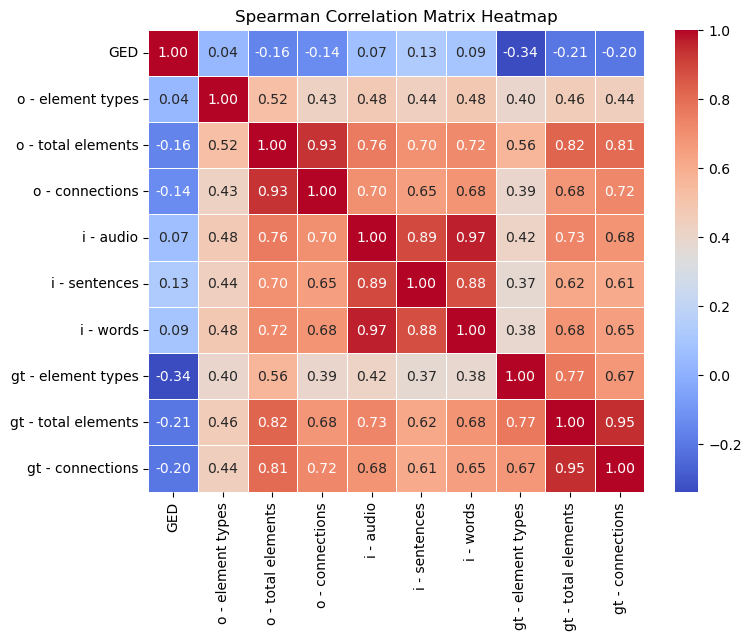

In [87]:
plt.figure(figsize=(8,6))
sns.heatmap(spearman_corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, xticklabels=[analysis_cols_naming.get(col, col) for col in full_df[analysis_cols].columns], yticklabels=[analysis_cols_naming.get(col, col) for col in full_df[analysis_cols].columns])
plt.title("Spearman Correlation Matrix Heatmap")

Comparison of GEDavg in Short vs. Long Audio groups:
             count      mean       std       min       25%       50%  \
audio_group                                                            
Long          21.0  0.654043  0.086131  0.463867  0.619566  0.656098   
Short         19.0  0.642773  0.082716  0.484647  0.593230  0.654135   

                  75%       max  
audio_group                      
Long         0.706431  0.807048  
Short        0.680974  0.805062   



<Figure size 640x480 with 0 Axes>

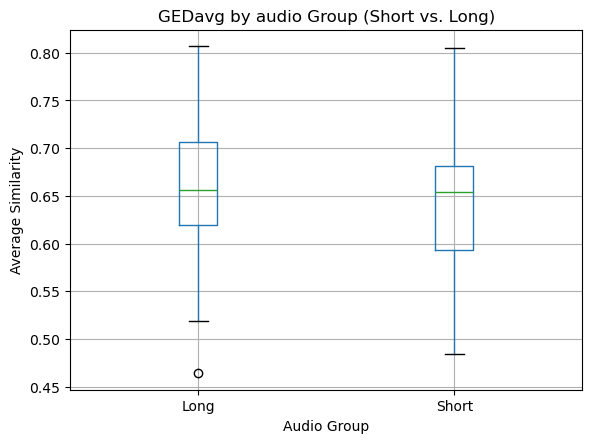

In [84]:
audio_cutoff = full_df["audio"].median()
full_df["audio_group"] = full_df["audio"].apply(lambda x: "Short" if x < audio_cutoff else "Long")
group_stats = full_df.groupby("audio_group")["GEDavg"].describe()
print("Comparison of GEDavg in Short vs. Long Audio groups:")
print(group_stats, "\n")
plt.figure()
full_df.boxplot(column="GEDavg", by="audio_group")
plt.title("GEDavg by audio Group (Short vs. Long)")
plt.suptitle("")
plt.xlabel("Audio Group")
plt.ylabel("Average Similarity")
plt.show()

In [41]:
pearson_r, pearson_p = pearsonr(full_df["GEDavg"], full_df["words"])
print(f"Pearson correlation (GEDavg vs. words): r={pearson_r:.3f}, p-value={pearson_p:.3f}")

spearman_r, spearman_p = spearmanr(full_df["GEDavg"], full_df["words"])
print(f"Spearman correlation (GEDavg vs. words): r={spearman_r:.3f}, p-value={spearman_p:.3f}\n")

Pearson correlation (GEDavg vs. words): r=0.090, p-value=0.580
Spearman correlation (GEDavg vs. words): r=0.091, p-value=0.576



Comparison of GEDavg in Short vs. Long words groups:
             count      mean       std       min       25%       50%  \
words_group                                                            
Long          20.0  0.647205  0.082315  0.463867  0.616431  0.640833   
Short         20.0  0.650173  0.087047  0.484647  0.594699  0.658816   

                  75%       max  
words_group                      
Long         0.689571  0.807048  
Short        0.685433  0.805062   



<Figure size 640x480 with 0 Axes>

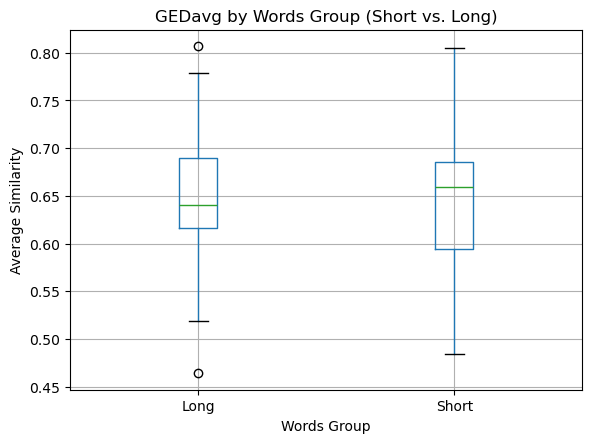

In [85]:
words_cutoff = full_df["words"].median()
full_df["words_group"] = full_df["words"].apply(lambda x: "Short" if x < words_cutoff else "Long")
group_stats = full_df.groupby("words_group")["GEDavg"].describe()
print("Comparison of GEDavg in Short vs. Long words groups:")
print(group_stats, "\n")
plt.figure()
full_df.boxplot(column="GEDavg", by="words_group")
plt.title("GEDavg by Words Group (Short vs. Long)")
plt.suptitle("")
plt.xlabel("Words Group")
plt.ylabel("Average Similarity")
plt.show()

In [45]:
low_threshold = 0.2
outliers = full_df[full_df["GEDavg"] < low_threshold]
print(f"Processes with GEDavg < {low_threshold}:")
print(outliers[["Process", "GEDavg", "words", "distinct elements"]], "\n")

Processes with GEDavg < 0.2:
Empty DataFrame
Columns: [Process, GEDavg, words, distinct elements]
Index: [] 



Comparison of GEDavg in Short vs. Long sentences groups:
                 count      mean       std       min       25%       50%  \
sentences_group                                                            
Long              21.0  0.661207  0.070901  0.518248  0.623241  0.665136   
Short             19.0  0.634854  0.095838  0.463867  0.593230  0.621057   

                      75%       max  
sentences_group                      
Long             0.706431  0.807048  
Short            0.680974  0.805062   



<Figure size 640x480 with 0 Axes>

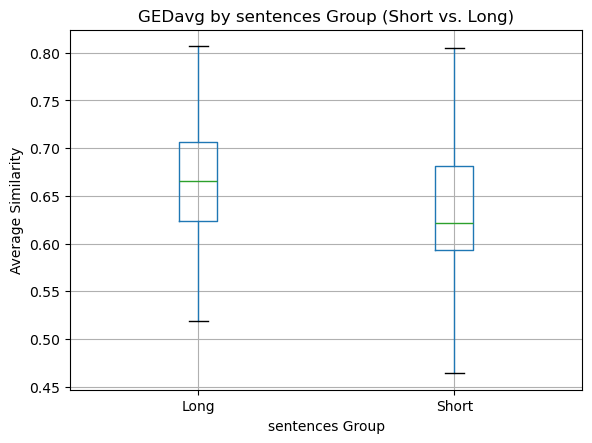

In [72]:
sentences_cutoff = full_df["sentences"].median()
full_df["sentences_group"] = full_df["sentences"].apply(lambda x: "Short" if x < sentences_cutoff else "Long")
group_stats = full_df.groupby("sentences_group")["GEDavg"].describe()
print("Comparison of GEDavg in Short vs. Long Sentences groups:")
print(group_stats, "\n")
plt.figure()
full_df.boxplot(column="GEDavg", by="sentences_group")
plt.title("GEDavg by sentences Group (Short vs. Long)")
plt.suptitle("")
plt.xlabel("sentences Group")
plt.ylabel("Average Similarity")
plt.show()

In [88]:
pearson_r, pearson_p = pearsonr(full_df["GEDavg"], full_df["distinct elements"])
print(f"Pearson correlation (GEDavg vs. distinct elements): r={pearson_r:.3f}, p-value={pearson_p:.3f}")

spearman_r, spearman_p = spearmanr(full_df["GEDavg"], full_df["distinct elements"])
print(f"Spearman correlation (GEDavg vs. distinct elements): r={spearman_r:.3f}, p-value={spearman_p:.3f}\n")

Pearson correlation (GEDavg vs. distinct elements): r=-0.264, p-value=0.105
Spearman correlation (GEDavg vs. distinct elements): r=-0.339, p-value=0.035



Comparison of GEDavg in Short vs. Long Distinct Elements groups:
                         count      mean       std       min       25%  \
distinct elements_group                                                  
Long                      20.0  0.613515  0.071445  0.463867  0.576144   
Short                     19.0  0.683998  0.083771  0.484647  0.639600   

                              50%       75%       max  
distinct elements_group                                
Long                     0.617269  0.665467  0.730518  
Short                    0.678385  0.742525  0.807048   



<Figure size 640x480 with 0 Axes>

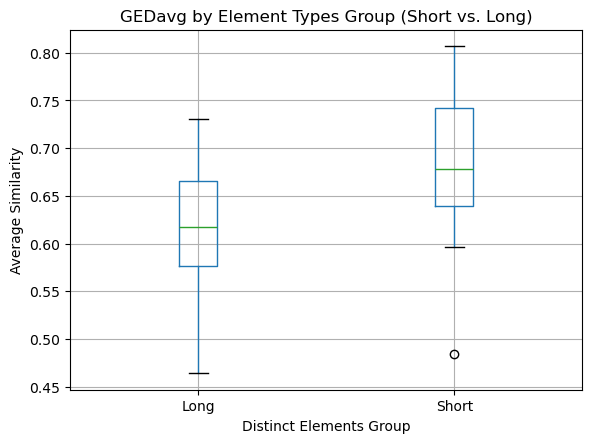

In [89]:
group_cutoff = full_df["distinct elements"].median()
full_df["distinct elements_group"] = full_df["distinct elements"].apply(lambda x: "Short" if x < group_cutoff else "Long")
group_stats = full_df.groupby("distinct elements_group")["GEDavg"].describe()
print("Comparison of GEDavg in Short vs. Long Distinct Elements groups:")
print(group_stats, "\n")
plt.figure()
full_df.boxplot(column="GEDavg", by="distinct elements_group")
plt.title("GEDavg by Element Types Group (Short vs. Long)")
plt.suptitle("")
plt.xlabel("Distinct Elements Group")
plt.ylabel("Average Similarity")
plt.show()

In [49]:
pearson_r, pearson_p = pearsonr(full_df["GEDavg"], full_df["total elements"])
print(f"Pearson correlation (GEDavg vs. total elements): r={pearson_r:.3f}, p-value={pearson_p:.3f}")

spearman_r, spearman_p = spearmanr(full_df["GEDavg"], full_df["total elements"])
print(f"Spearman correlation (GEDavg vs. total elements): r={spearman_r:.3f}, p-value={spearman_p:.3f}\n")

Pearson correlation (GEDavg vs. total elements): r=-0.178, p-value=0.271
Spearman correlation (GEDavg vs. total elements): r=-0.212, p-value=0.189



Comparison of GEDavg in Short vs. Long Connections groups:
                   count      mean       std       min       25%       50%  \
connections_group                                                            
Long                20.0  0.632662  0.066971  0.463867  0.602724  0.640833   
Short               20.0  0.664717  0.096601  0.484647  0.597539  0.659636   

                        75%       max  
connections_group                      
Long               0.674417  0.724319  
Short              0.742543  0.807048   



<Figure size 640x480 with 0 Axes>

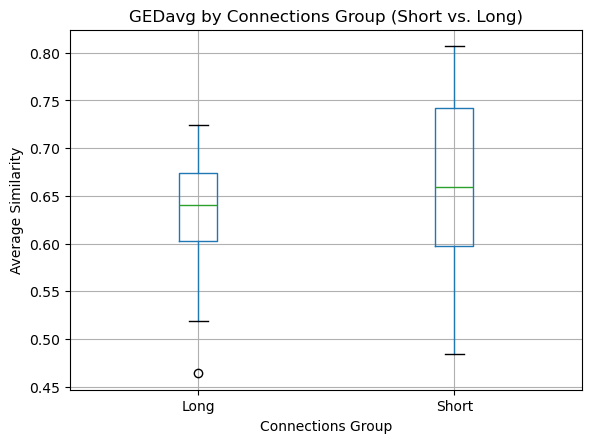

In [88]:
group_cutoff = full_df["connections"].median()
full_df["connections_group"] = full_df["connections"].apply(lambda x: "Short" if x < group_cutoff else "Long")
group_stats = full_df.groupby("connections_group")["GEDavg"].describe()
print("Comparison of GEDavg in Short vs. Long Connections groups:")
print(group_stats, "\n")
plt.figure()
full_df.boxplot(column="GEDavg", by="connections_group")
plt.title("GEDavg by Connections Group (Short vs. Long)")
plt.suptitle("")
plt.xlabel("Connections Group")
plt.ylabel("Average Similarity")
plt.show()

### 3.5 Error Analysis

In [90]:
error_data.shape

(21, 18)

In [94]:
attributes=["GED", "sentences", "words", "resultDistinct", "resultElements", "resultConnections"]

Error type frequencies messageFlow                 11
missingFlow                  4
flowCrossingPoolBoundary     4
gatewayWithoutFunction       4
wrongFlow                    2
dtype: int64


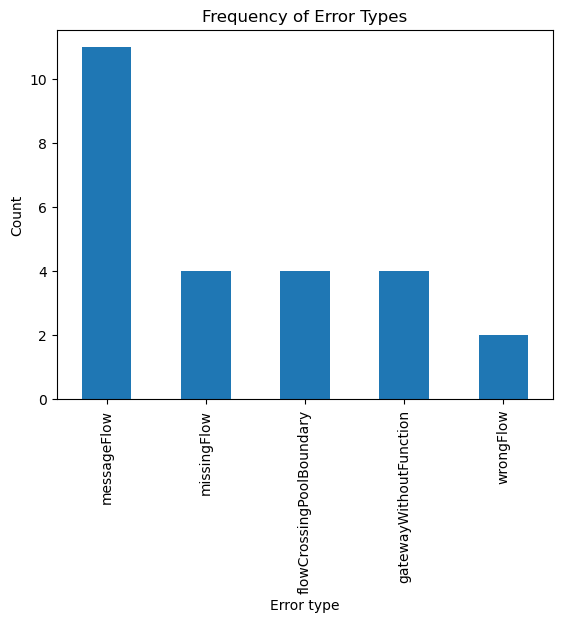

In [92]:
error_cols = ["messageFlow", "missingFlow", "flowCrossingPoolBoundary", "gatewayWithoutFunction", "wrongFlow"]
error_type_counts = error_data[error_cols].sum().sort_values(ascending=False)
print("Error type frequencies", error_type_counts)
plt.figure()
error_type_counts.plot(kind='bar')
plt.title('Frequency of Error Types')
plt.ylabel('Count')
plt.xlabel('Error type')
plt.show()

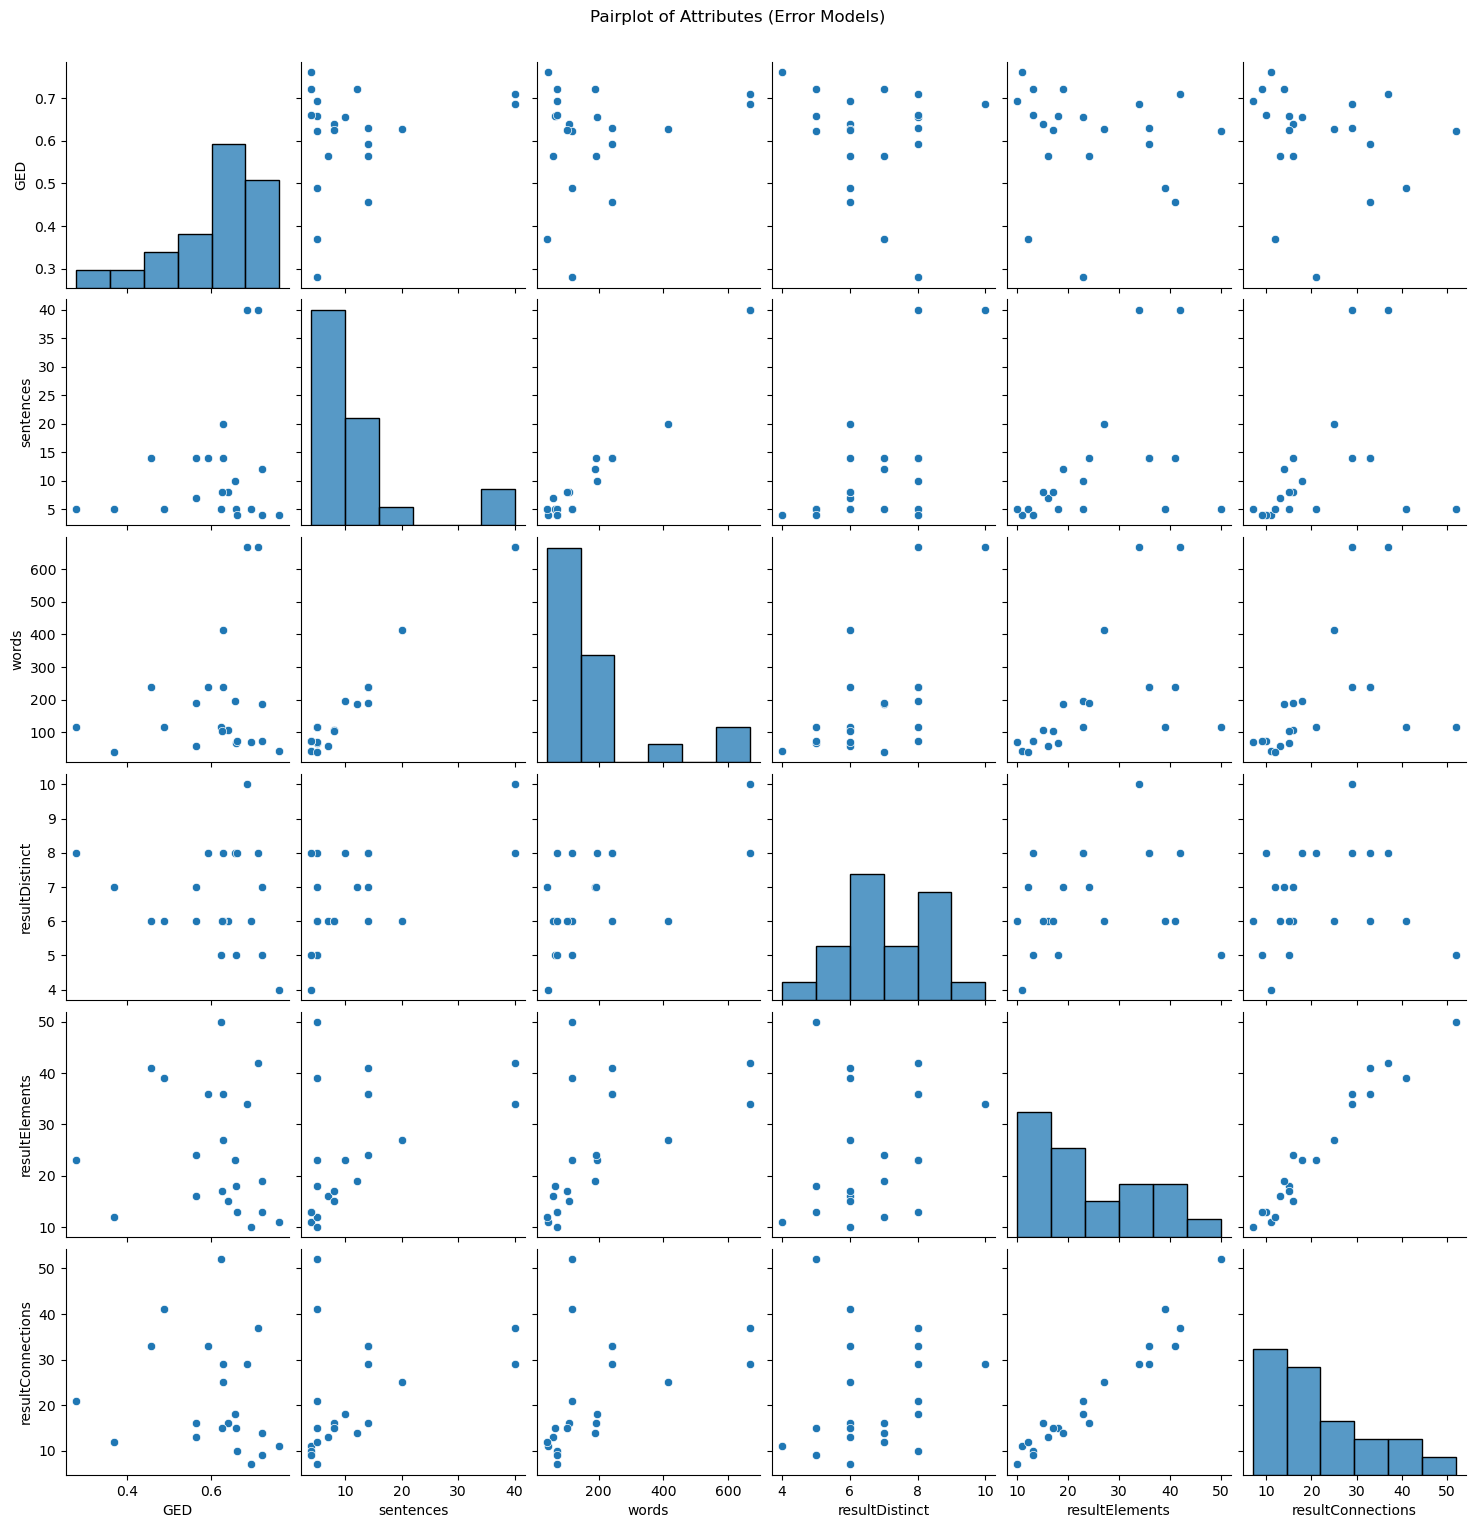

In [37]:
sns.pairplot(error_data[attributes])
plt.suptitle('Pairplot of Attributes (Error Models)', y=1.02)
plt.show()

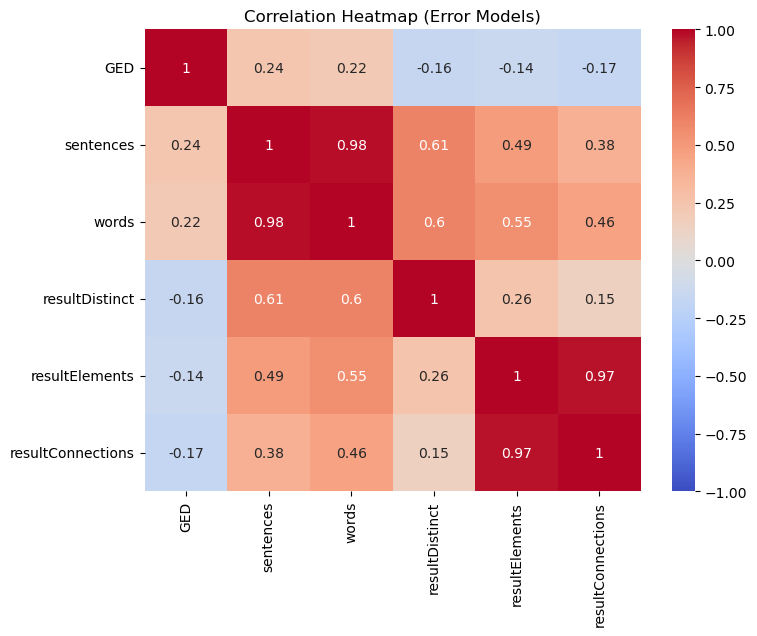

In [38]:
plt.figure(figsize=(8, 6))
corr = error_data[attributes].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap (Error Models)')
plt.show()

In [96]:
error_data["error"] = "Error"
non_error_data["error"] = "No Error"
combined_error = pd.concat([error_data, non_error_data], ignore_index=True)

<Figure size 600x400 with 0 Axes>

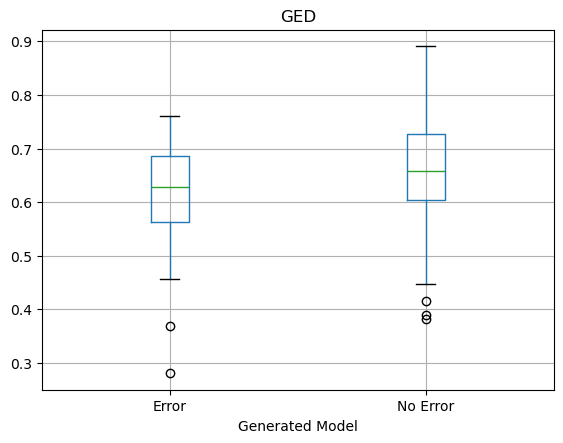

<Figure size 600x400 with 0 Axes>

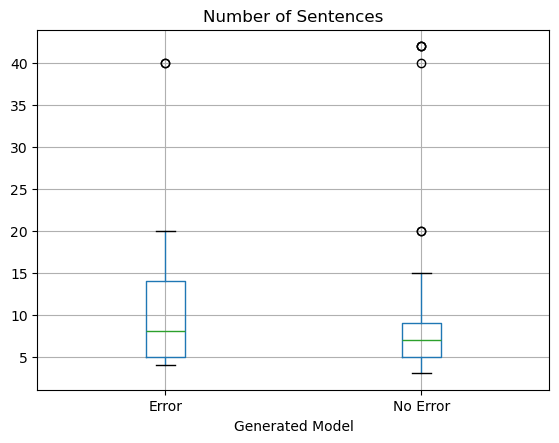

<Figure size 600x400 with 0 Axes>

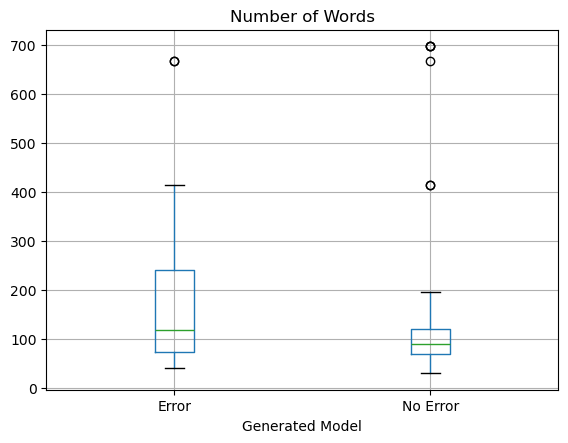

<Figure size 600x400 with 0 Axes>

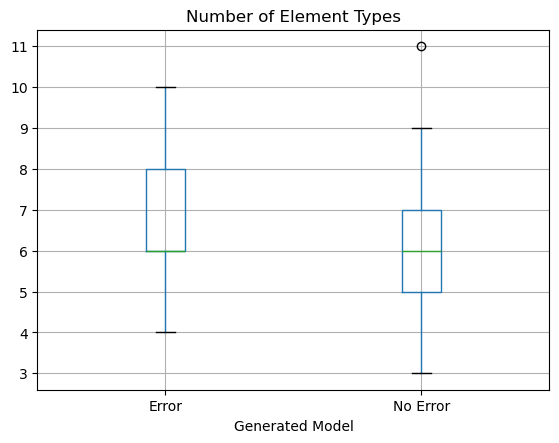

<Figure size 600x400 with 0 Axes>

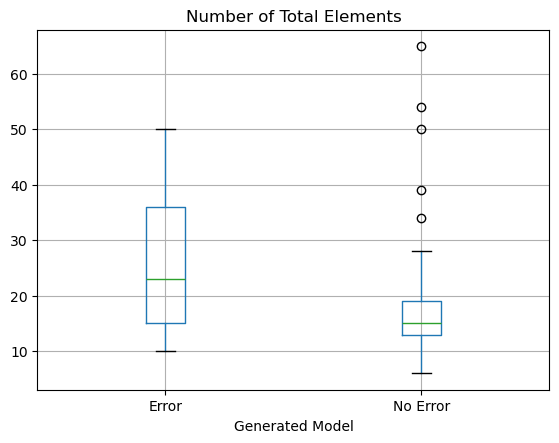

<Figure size 600x400 with 0 Axes>

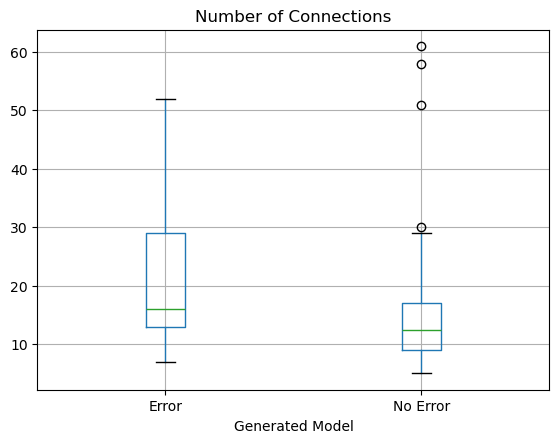

In [97]:
names = {
    'GED': 'GED', 
    'sentences': 'Number of Sentences', 
    'words': "Number of Words", 
    'resultDistinct': "Number of Element Types", 
    'resultElements': "Number of Total Elements", 
    'resultConnections': "Number of Connections"
}
for attr in attributes:
    plt.figure(figsize=(6,4))
    combined_error.boxplot(column=attr, by='error')
    plt.title(f'{names[attr]}')
    plt.suptitle('')
    plt.xlabel('Generated Model')
    plt.ylabel('')
    plt.show()